# Capture YouTube Live
> This module is used to capture images from YouTube live.

In [ ]:
#| default_exp ninjalabo.llmcam.capture_youtube_live

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import yt_dlp as youtube_dl

In [ ]:
#| export
youtube_live_url = "https://www.youtube.com/watch?v=LMZQ7eFhm58"
ydl_opts = {
    'cookiefile': "cookies.txt",  # Path to the exported cookies file,  # Use cookies for authentication
    'download': False  # Set to True if you want to download
}

In [ ]:
with youtube_dl.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(youtube_live_url, download=False)
    for o in info['formats']:
        if o['resolution'] == '1280x720':
            print(o['url'])
            break
    else:
        raise ValueError("No 1280x720 format")

[youtube] Extracting URL: https://www.youtube.com/watch?v=LMZQ7eFhm58
[youtube] LMZQ7eFhm58: Downloading webpage
[youtube] LMZQ7eFhm58: Downloading ios player API JSON
[youtube] LMZQ7eFhm58: Downloading web creator player API JSON
[youtube] LMZQ7eFhm58: Downloading m3u8 information
https://manifest.googlevideo.com/api/manifest/hls_playlist/expire/1729612379/ei/-3UXZ6zEBrGTv_IP8pmgiAo/ip/2001:708:150:10::1eda/id/LMZQ7eFhm58.4/itag/232/source/yt_live_broadcast/requiressl/yes/ratebypass/yes/live/1/sgovp/gir%3Dyes%3Bitag%3D136/rqh/1/hdlc/1/hls_chunk_host/rr2---sn-ovgq0oxu-5goe.googlevideo.com/xpc/EgVo2aDSNQ%3D%3D/playlist_duration/3600/manifest_duration/3600/vprv/1/playlist_type/DVR/met/1729590779,/mh/l8/mm/44/mn/sn-ovgq0oxu-5goe/ms/lva/mv/u/mvi/2/pl/44/rms/lva,lva/dover/13/pacing/0/short_key/1/keepalive/yes/fexp/51312688,51326931/mt/1729587330/sparams/expire,ei,ip,id,itag,source,requiressl,ratebypass,live,sgovp,rqh,hdlc,xpc,playlist_duration,manifest_duration,vprv,playlist_type/sig/AJfQdS

In [ ]:
#| export
import cv2
import yt_dlp as youtube_dl
import time
from IPython.display import Image, display
from pathlib import Path

class YouTubeLive:
    def __init__(self, url="https://www.youtube.com/watch?v=LMZQ7eFhm58"):
        self.youtube_live_url = url
        self.stream_live_url = self.stream_url(url)
    
    def stream_url(self, youtube_live_url):
        assert self.youtube_live_url != None, "self.youtube_live_url == None"
        with youtube_dl.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(youtube_live_url, download=False)
            for o in info['formats']:
                if o['resolution'] == '1280x720':
                    return o['url']
            raise ValueError("No 1280x720 format")
            return None
    
    def capture_frame(self, crop_region=None):
        """Capture a frame from the live stream with cropped a region"""
        assert self.stream_live_url != None
        cap = cv2.VideoCapture(self.stream_live_url)
        if not cap.isOpened():
            print("Error: Could not open video stream.")
            return None
    
        ret, frame = cap.read()
        if ret:
            if crop_region:
                x, y, w, h = crop_region
                frame = frame[y:y+h, x:x+w]
            path = Path("../data")/("frame_" + str(int(time.time())) + ".jpg")
            cv2.imwrite(path, frame)
            print(path)
            return path
        else:
            print("Error: Could not capture frame.")
            return None

    def capture_frames(self):
        for i in range(9999):
            print(i, end=": ")
            self.capture_frame()
            time.sleep(80)

    def dump(self, format=None):
        #display(Image(self.capture_frame((0,0,500,30))))
        display(Image(self.capture_frame()))

[youtube] Extracting URL: https://www.youtube.com/watch?v=LMZQ7eFhm58
[youtube] LMZQ7eFhm58: Downloading webpage
[youtube] LMZQ7eFhm58: Downloading ios player API JSON
[youtube] LMZQ7eFhm58: Downloading web creator player API JSON
[youtube] LMZQ7eFhm58: Downloading m3u8 information
../data/frame_1729590922.jpg


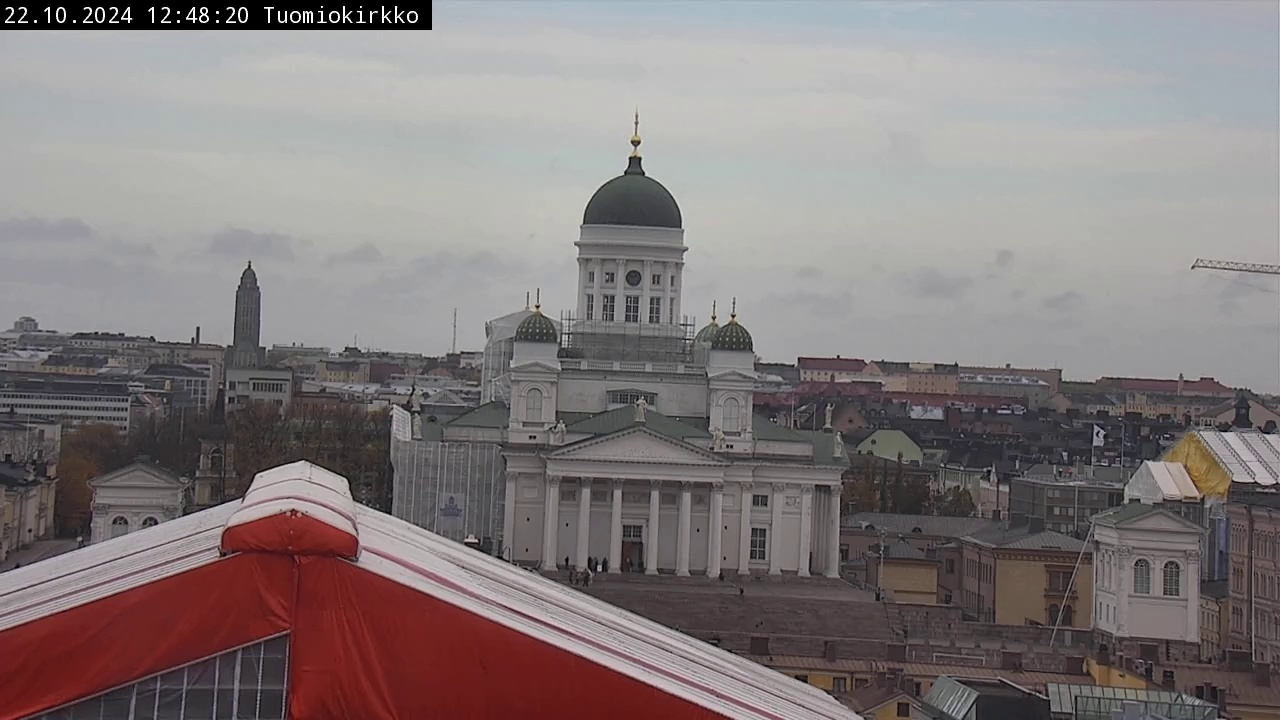

In [ ]:
YouTubeLive().dump()

In [ ]:
#YouTubeLive().capture_frames()

[youtube] Extracting URL: https://www.youtube.com/watch?v=LMZQ7eFhm58
[youtube] LMZQ7eFhm58: Downloading webpage
[youtube] LMZQ7eFhm58: Downloading ios player API JSON
[youtube] LMZQ7eFhm58: Downloading web creator player API JSON
[youtube] LMZQ7eFhm58: Downloading m3u8 information
0: ../data/frame_1728573748.jpg
1: ../data/frame_1728573829.jpg
2: ../data/frame_1728573910.jpg
3: ../data/frame_1728573990.jpg


KeyboardInterrupt: 

In [ ]:
import glob
glob.glob('../data/*.jpg')

['../data/frame_1728043212.jpg',
 '../data/frame_1728043403.jpg',
 '../data/frame_1728240209.jpg',
 '../data/frame_1727625655.jpg',
 '../data/frame_1728043225.jpg',
 '../data/frame_1728109783.jpg',
 '../data/frame_1728231053.jpg',
 '../data/frame_1728043194.jpg',
 '../data/frame_1728234908.jpg',
 '../data/frame_1728295218.jpg',
 '../data/frame_1728240611.jpg',
 '../data/frame_1727679276.jpg',
 '../data/frame_1728248091.jpg',
 '../data/frame_1728295860.jpg',
 '../data/frame_1728295138.jpg',
 '../data/frame_1727626996.jpg',
 '../data/frame_1728291686.jpg',
 '../data/frame_1728109763.jpg',
 '../data/frame_1728250985.jpg',
 '../data/frame_1728230089.jpg',
 '../data/frame_1728246723.jpg',
 '../data/frame_1727627107.jpg',
 '../data/frame_1727678943.jpg',
 '../data/frame_1727544187.jpg',
 '../data/frame_1728109773.jpg',
 '../data/frame_1727544516.jpg',
 '../data/frame_1727600910.jpg',
 '../data/frame_1728296502.jpg',
 '../data/frame_1727529119.jpg',
 '../data/frame_1728245676.jpg',
 '../data/

In [ ]:
# from pathlib import Path
# from PIL import Image
# import pytesseract

# def datetime_and_place(image_path):
#     places = [
#         "Olympiaterminaali",
#         "Etelasatama",
#         "Presidentinlinna",
#         "Tuomiokirkko",
#         "Kauppatori",
#         "Torni",
#     ]
#     title_rectangle = (0,0,500,30)
#     image = Image.open(image_path).crop(title_rectangle)
#     text = pytesseract.image_to_string(image).strip()
#     date_obj = datetime.strptime(text[:19], "%d.%m.%Y %H:%M:%S")
#     for i, p in enumerate(places):
#         if p in text[20:]:
#             return date_obj, places[i]
    
# for o in Path('.').glob('*.jpg'):
#     try:
#         datetime, place = datetime_and_place(o)
#         print(f"{o.name}: {datetime} {place}")
#     except:
#         print(f"Removing {o.name}")
#         o.unlink()

Removing frame_1728130670.jpg
Removing frame_1728130750.jpg
Removing frame_1728130757.jpg
Removing frame_1728205824.jpg
Removing frame_1728130623.jpg
Removing frame_1728130746.jpg
Removing frame_1728130696.jpg
Removing frame_1728130733.jpg
Removing frame_1728204693.jpg
Removing frame_1728130673.jpg
Removing frame_1728203142.jpg
Removing frame_1728130651.jpg
Removing frame_1728205178.jpg
Removing frame_1728130632.jpg
Removing frame_1728130621.jpg
Removing frame_1728203143.jpg
Removing frame_1728203152.jpg
Removing frame_1728207357.jpg
Removing frame_1728203724.jpg
Removing frame_1728207519.jpg
Removing frame_1728206228.jpg
Removing frame_1728130684.jpg
Removing frame_1728130755.jpg
Removing frame_1728130731.jpg
Removing frame_1728130666.jpg
Removing frame_1728208246.jpg
Removing frame_1728130712.jpg
Removing frame_1728205905.jpg
Removing frame_1728130675.jpg
Removing frame_1728207438.jpg
Removing frame_1728206631.jpg
Removing frame_1728130618.jpg
Removing frame_1728208569.jpg
Removing f

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()